# Loan Approval Prediction — Fairness & Explainability

**CS465 Machine Learning Project**

This notebook implements the full pipeline:
1. **EDA** — dataset characterization and visualisation
2. **Preprocessing** — 60/20/20 stratified split + feature engineering + encoding + scaling
3. **Modeling** — Logistic Regression (baseline), Random Forest, Gradient Boosting, XGBoost
4. **Fairness evaluation** — Demographic Parity & Equalized Odds on `age_bin` and `occupation_status`
5. **Explainability** — SHAP on the best tree-based model

## 0. Setup

In [ ]:
#!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost fairlearn shap


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [ ]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from xgboost import XGBClassifier

from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference, equalized_odds_difference,
    true_positive_rate, false_positive_rate, selection_rate
)
import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

## 1. Load Data

The dataset is the *Realistic Loan Approval Dataset (US & Canada)* from Kaggle. It contains 50,000 applications and 20 features.

In [ ]:
df = pd.read_csv("Loan_approval_data_2025.csv")
print("Shape:", df.shape)
print("Missing values total:", df.isnull().sum().sum())
print("\nTarget distribution:")
print(df["loan_status"].value_counts())
print(f"\nApproval rate: {df['loan_status'].mean():.2%}")
df.head()

Shape: (50000, 20)
Missing values total: 0

Target distribution:
loan_status
1    27523
0    22477
Name: count, dtype: int64

Approval rate: 55.05%


,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


## 2. Exploratory Data Analysis

We separate the features into:
- **Applicant demographics**: `age`, `occupation_status`, `years_employed`
- **Financial status**: `annual_income`, `savings_assets`, `current_debt`, `debt_to_income_ratio`
- **Credit history**: `credit_score`, `credit_history_years`, `defaults_on_file`, `delinquencies_last_2yrs`, `derogatory_marks`
- **Loan characteristics**: `product_type`, `loan_intent`, `loan_amount`, `interest_rate`, `loan_to_income_ratio`, `payment_to_income_ratio`

### 2.1 Target distribution

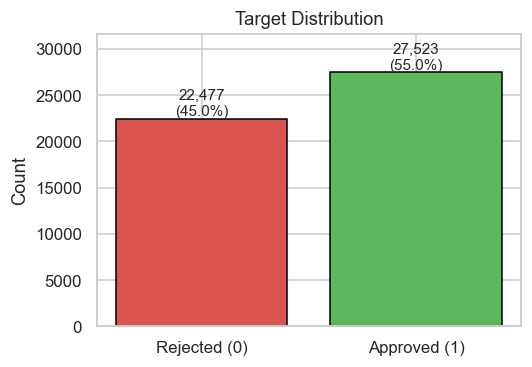

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
counts = df["loan_status"].value_counts().sort_index()
bars = ax.bar(["Rejected (0)", "Approved (1)"], counts.values,
              color=["#d9534f", "#5cb85c"], edgecolor="black")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 300,
            f"{val:,}\n({val/len(df):.1%})", ha="center", fontsize=10)
ax.set_ylabel("Count"); ax.set_title("Target Distribution")
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout(); plt.show()

The target is mildly imbalanced (55% approved / 45% rejected). its not that  extreme require resample the data, but it does motivate reporting F1, precision, and recall rather than relying on accuracy alone.

### 2.2 Numeric feature distributions

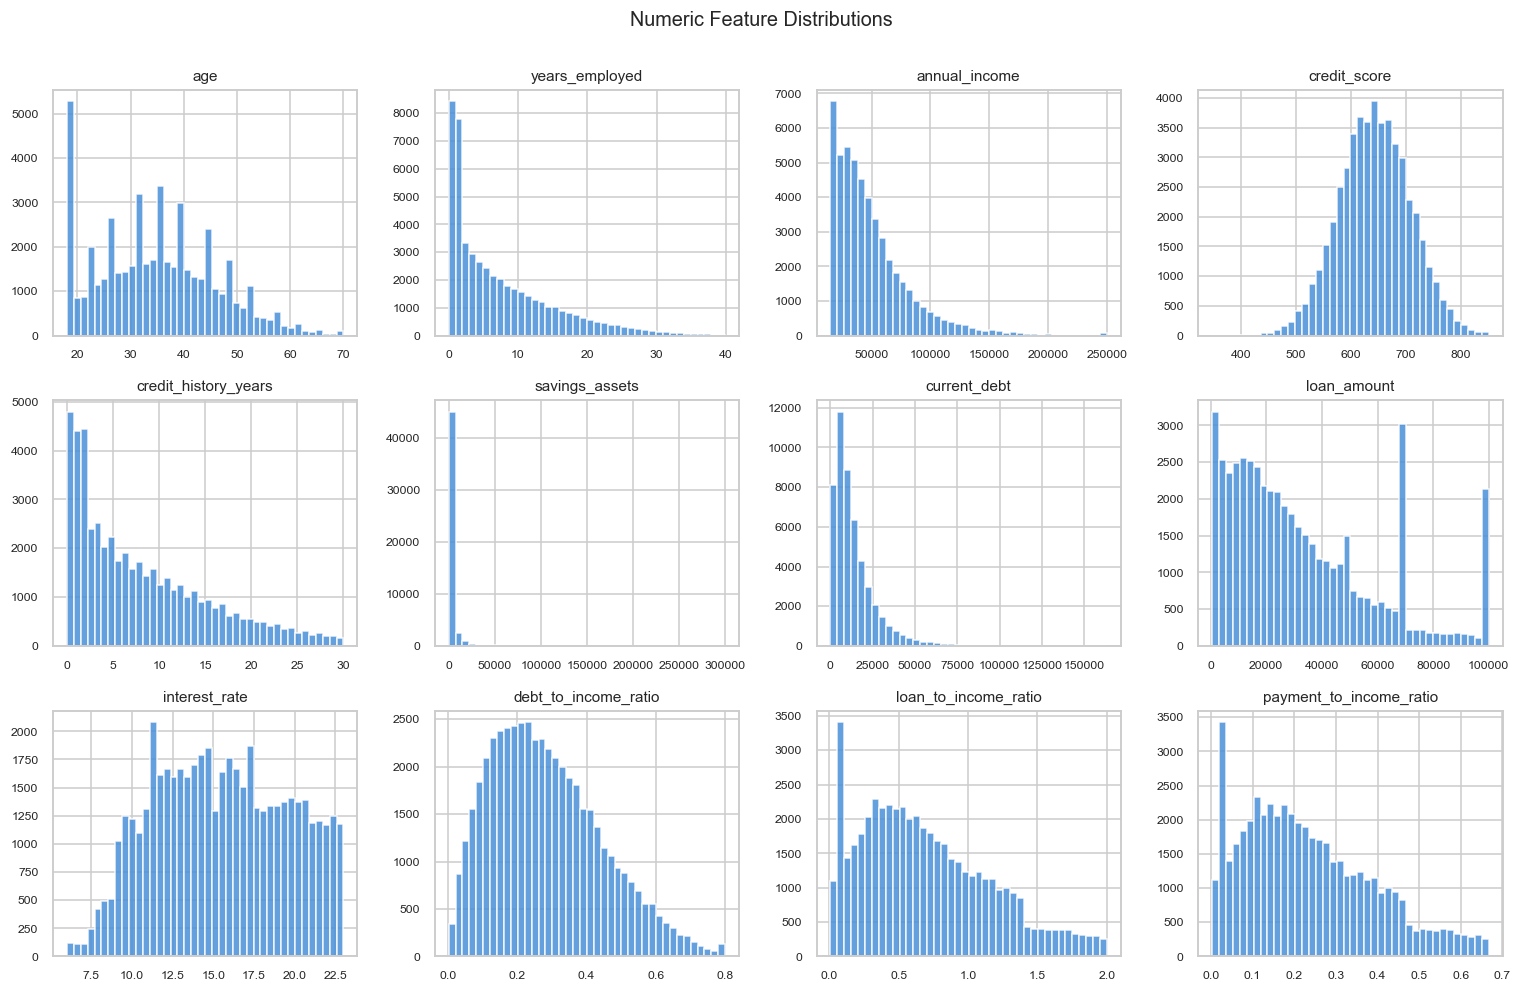

In [ ]:
numeric_cols = ["age", "years_employed", "annual_income", "credit_score",
                "credit_history_years", "savings_assets", "current_debt",
                "loan_amount", "interest_rate", "debt_to_income_ratio",
                "loan_to_income_ratio", "payment_to_income_ratio"]

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(df[col], bins=40, color="#4a90d9", edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
plt.suptitle("Numeric Feature Distributions", fontsize=13, y=1.00)
plt.tight_layout(); plt.show()

### 2.3 Approval rate across categorical groups (fairness motivation)

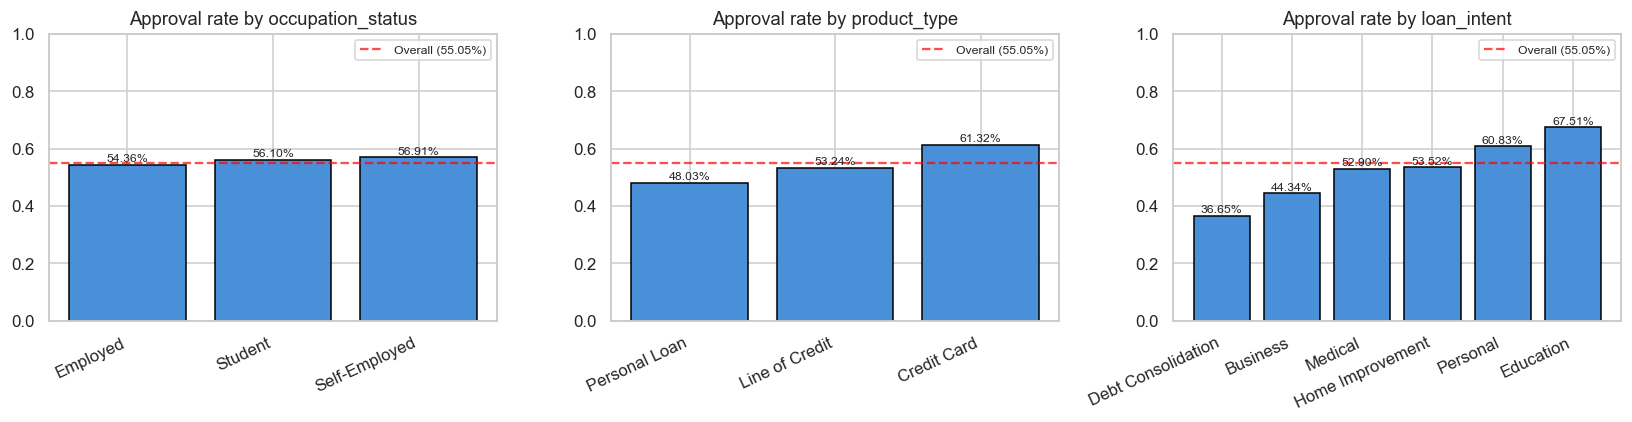

In [ ]:
cat_cols = ["occupation_status", "product_type", "loan_intent"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, cat_cols):
    rates = df.groupby(col)["loan_status"].mean().sort_values()
    bars = ax.bar(rates.index, rates.values, color="#4a90d9", edgecolor="black")
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f"{val:.2%}", ha="center", fontsize=8)
    ax.axhline(df["loan_status"].mean(), ls="--", color="red", alpha=0.7,
               label=f"Overall ({df['loan_status'].mean():.2%})")
    ax.set_title(f"Approval rate by {col}"); ax.legend(fontsize=8)
    ax.set_ylim(0, 1)
    for label in ax.get_xticklabels():
        label.set_rotation(25); label.set_ha("right")
plt.tight_layout(); plt.show()

Observation:
Occupations have almost identical approval percentages (54% to 57%). On the other hand, there is a big difference between the percentages for the loan_intent feature (37% Debt Consolidation vs. 68% Education). The differences observed in the base rates are the reason for the fairness behavior observed further down.

### 2.4 Correlation heatmap

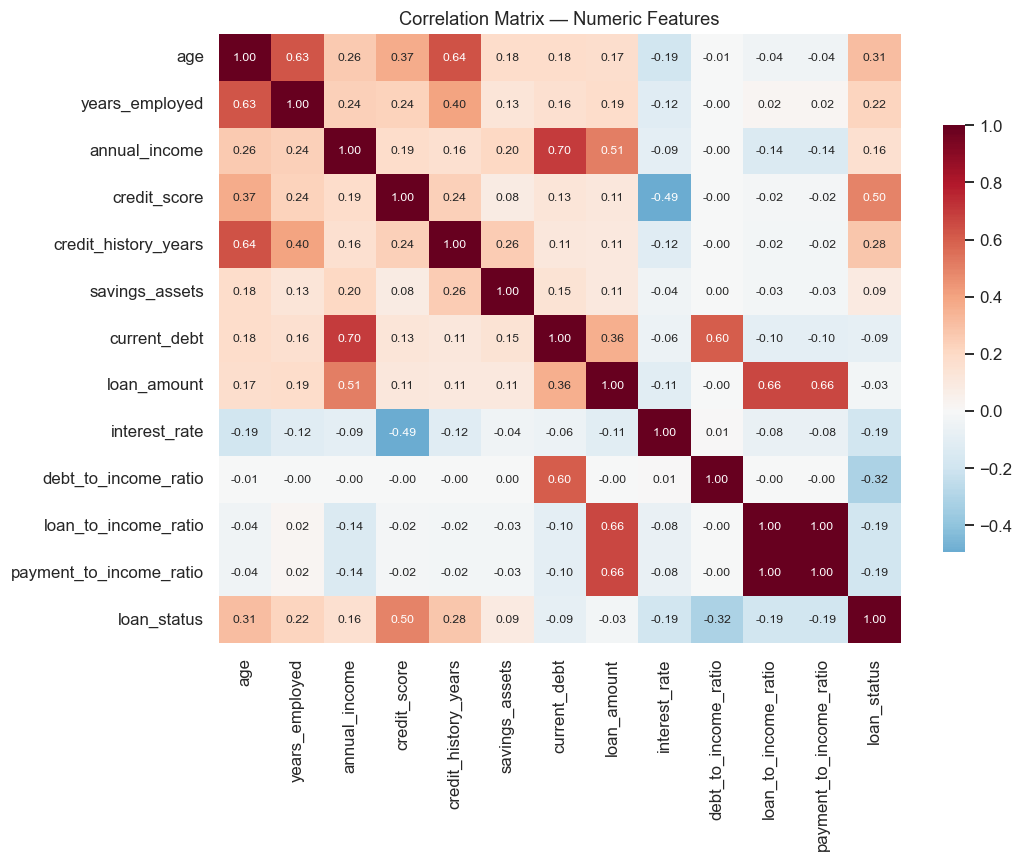

In [ ]:
corr = df[numeric_cols + ["loan_status"]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            annot_kws={"size": 8}, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout(); plt.show()

`credit_score` has the strongest positive correlation with `loan_status`. `debt_to_income_ratio`, `interest_rate`, and `loan_to_income_ratio` all correlate negatively, as expected.

## 3. Preprocessing & Feature Engineering

### 3.1 Train / Validation / Test split (60 / 20 / 20, stratified)

In [ ]:
target_col = "loan_status"
id_col = "customer_id"
X = df.drop(columns=[target_col, id_col])
y = df[target_col]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"\nClass balance — train: {y_train.mean():.3f}, val: {y_val.mean():.3f}, test: {y_test.mean():.3f}")

Train: (30000, 18) | Val: (10000, 18) | Test: (10000, 18)

Class balance — train: 0.550, val: 0.550, test: 0.550


### 3.2 Feature engineering

We derive four new features and three bin features. All are computed from non-target columns (no leakage).

In [ ]:
def engineer_features(df_in):
    d = df_in.copy()
    # 1. Net financial position
    d["income_minus_debt"] = d["annual_income"] - d["current_debt"]
    # 2. Credit score normalised by credit history length
    d["credit_score_per_year"] = d["credit_score"] / (d["credit_history_years"] + 1)
    # 3. Loan interest burden (amount × rate)
    d["loan_interest_burden"] = d["loan_amount"] * d["interest_rate"]
    # 4. Aggregate risk flags
    d["total_risk_flags"] = (d["defaults_on_file"] + d["delinquencies_last_2yrs"]
                             + d["derogatory_marks"])
    # 5. Ordered bins
    d["credit_score_bin"] = pd.cut(d["credit_score"],
                                    bins=[300, 580, 670, 740, 850],
                                    labels=["poor", "fair", "good", "excellent"])
    d["age_bin"] = pd.cut(d["age"], bins=[17, 30, 50, 100],
                          labels=["young", "mid", "senior"])
    d["income_bin"] = pd.qcut(d["annual_income"], q=3,
                              labels=["low", "medium", "high"])
    return d

X_train_fe = engineer_features(X_train)
X_val_fe   = engineer_features(X_val)
X_test_fe  = engineer_features(X_test)

print(f"After feature engineering: {X_train_fe.shape[1]} features")
print("New columns:", sorted(set(X_train_fe.columns) - set(X_train.columns)))

After feature engineering: 25 features
New columns: ['age_bin', 'credit_score_bin', 'credit_score_per_year', 'income_bin', 'income_minus_debt', 'loan_interest_burden', 'total_risk_flags']


### 3.3 One-hot encoding + standardisation

In [ ]:
cat_cols_all = ["occupation_status", "product_type", "loan_intent",
                "credit_score_bin", "age_bin", "income_bin"]

X_train_enc = pd.get_dummies(X_train_fe, columns=cat_cols_all, drop_first=True)
X_val_enc   = pd.get_dummies(X_val_fe,   columns=cat_cols_all, drop_first=True)
X_test_enc  = pd.get_dummies(X_test_fe,  columns=cat_cols_all, drop_first=True)

# Align validation/test columns to training
X_val_enc  = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Cast booleans to float for model compatibility
X_train_enc = X_train_enc.astype(float)
X_val_enc   = X_val_enc.astype(float)
X_test_enc  = X_test_enc.astype(float)

# Scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_val_scaled   = scaler.transform(X_val_enc)
X_test_scaled  = scaler.transform(X_test_enc)

print(f"Final feature count: {X_train_enc.shape[1]}")

Final feature count: 35


## 4. Model Training & Evaluation

We train four supervised classifiers with the same splits and the same feature representation.

In [ ]:
models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "X_train": X_train_scaled, "X_val": X_val_scaled, "X_test": X_test_scaled,
    },
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=300, max_depth=12,
                                        min_samples_leaf=5, n_jobs=-1,
                                        random_state=RANDOM_STATE),
        "X_train": X_train_enc.values, "X_val": X_val_enc.values,
        "X_test": X_test_enc.values,
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                            learning_rate=0.1,
                                            random_state=RANDOM_STATE),
        "X_train": X_train_enc.values, "X_val": X_val_enc.values,
        "X_test": X_test_enc.values,
    },
    "XGBoost": {
        "model": XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                               subsample=0.9, colsample_bytree=0.9,
                               eval_metric="logloss", random_state=RANDOM_STATE,
                               n_jobs=-1, verbosity=0),
        "X_train": X_train_enc.values, "X_val": X_val_enc.values,
        "X_test": X_test_enc.values,
    },
}


def eval_model(clf, X, y):
    y_pred = clf.predict(X)
    y_prob = clf.predict_proba(X)[:, 1]
    return {
        "accuracy":  accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall":    recall_score(y, y_pred),
        "f1":        f1_score(y, y_pred),
        "auc":       roc_auc_score(y, y_prob),
        "y_pred":    y_pred,
        "y_prob":    y_prob,
    }


results = {}
for name, spec in models.items():
    print(f"-- Training {name} ...")
    clf = spec["model"].fit(spec["X_train"], y_train)
    results[name] = {
        "model": clf,
        "val":  eval_model(clf, spec["X_val"],  y_val),
        "test": eval_model(clf, spec["X_test"], y_test),
    }
print("\nAll models trained.")

-- Training Logistic Regression ...
-- Training Random Forest ...
-- Training Gradient Boosting ...
-- Training XGBoost ...

All models trained.


### 4.1 Summary of test-set metrics

In [ ]:
rows = []
for name, r in results.items():
    for split in ("val", "test"):
        rows.append({
            "Model": name, "Split": split,
            "Accuracy":  r[split]["accuracy"],
            "Precision": r[split]["precision"],
            "Recall":    r[split]["recall"],
            "F1":        r[split]["f1"],
            "AUC":       r[split]["auc"],
        })
summary_df = pd.DataFrame(rows)
summary_df.round(4)

,Model,Split,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,val,0.8722,0.8766,0.8935,0.8850,0.9472
1,Logistic Regression,test,0.8701,0.8759,0.8901,0.8830,0.9476
2,Random Forest,val,0.8970,0.8965,0.9190,0.9076,0.9658
3,Random Forest,test,0.8988,0.8953,0.9243,0.9095,0.9667
4,Gradient Boosting,val,0.9275,0.9275,0.9419,0.9346,0.9843
5,Gradient Boosting,test,0.9263,0.9248,0.9428,0.9337,0.9838
6,XGBoost,val,0.9265,0.9293,0.9379,0.9335,0.9839
7,XGBoost,test,0.9238,0.9219,0.9413,0.9315,0.9831


### 4.2 Metric comparison bar chart

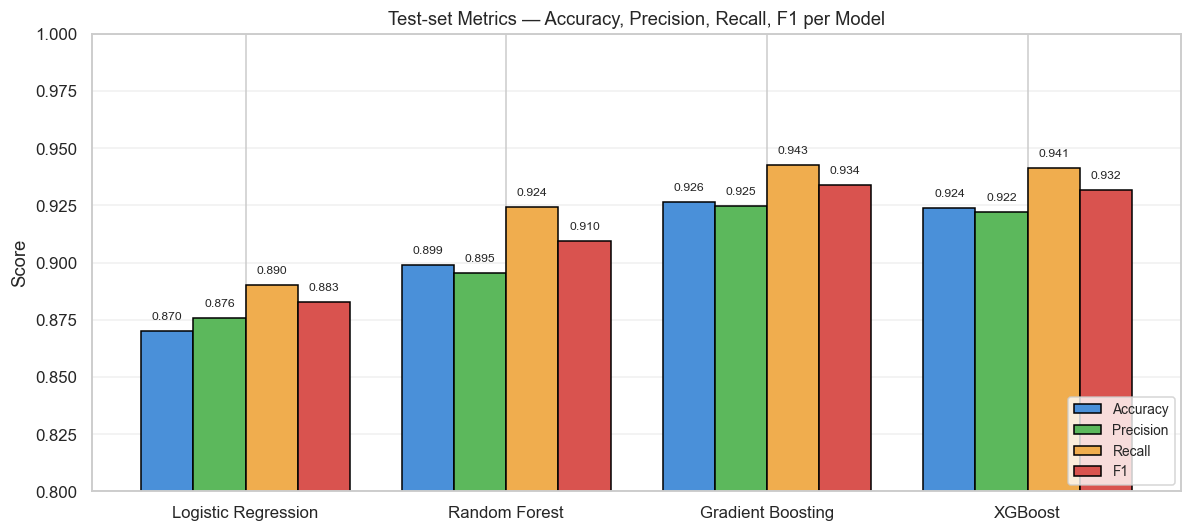

In [ ]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1"]
test_df = summary_df[summary_df["Split"] == "test"].set_index("Model")
model_names = list(models.keys())

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(model_names))
width = 0.2
metric_colors = ["#4a90d9", "#5cb85c", "#f0ad4e", "#d9534f"]

for i, metric in enumerate(metrics_to_plot):
    vals = [test_df.loc[name, metric] for name in model_names]
    bars = ax.bar(x + i * width, vals, width, label=metric,
                  color=metric_colors[i], edgecolor="black")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                f"{val:.3f}", ha="center", fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names)
ax.set_ylim(0.80, 1.0)
ax.set_ylabel("Score")
ax.set_title("Test-set Metrics — Accuracy, Precision, Recall, F1 per Model")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

### 4.3 ROC curves

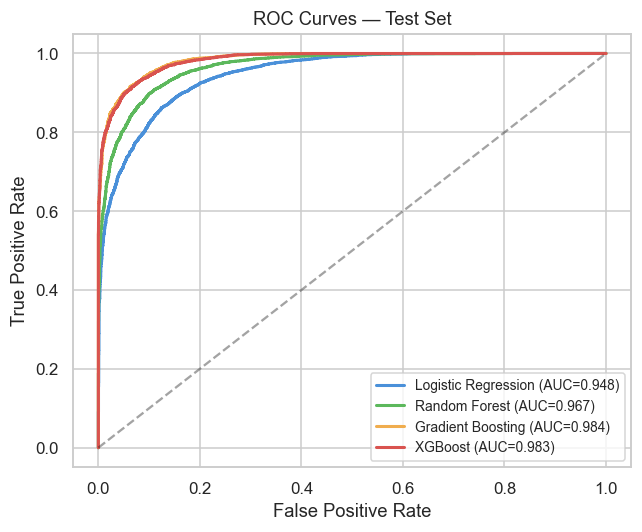

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for i, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, r["test"]["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['test']['auc']:.3f})",
            color=colors[i], lw=2)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Test Set")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

### 4.4 Confusion matrices

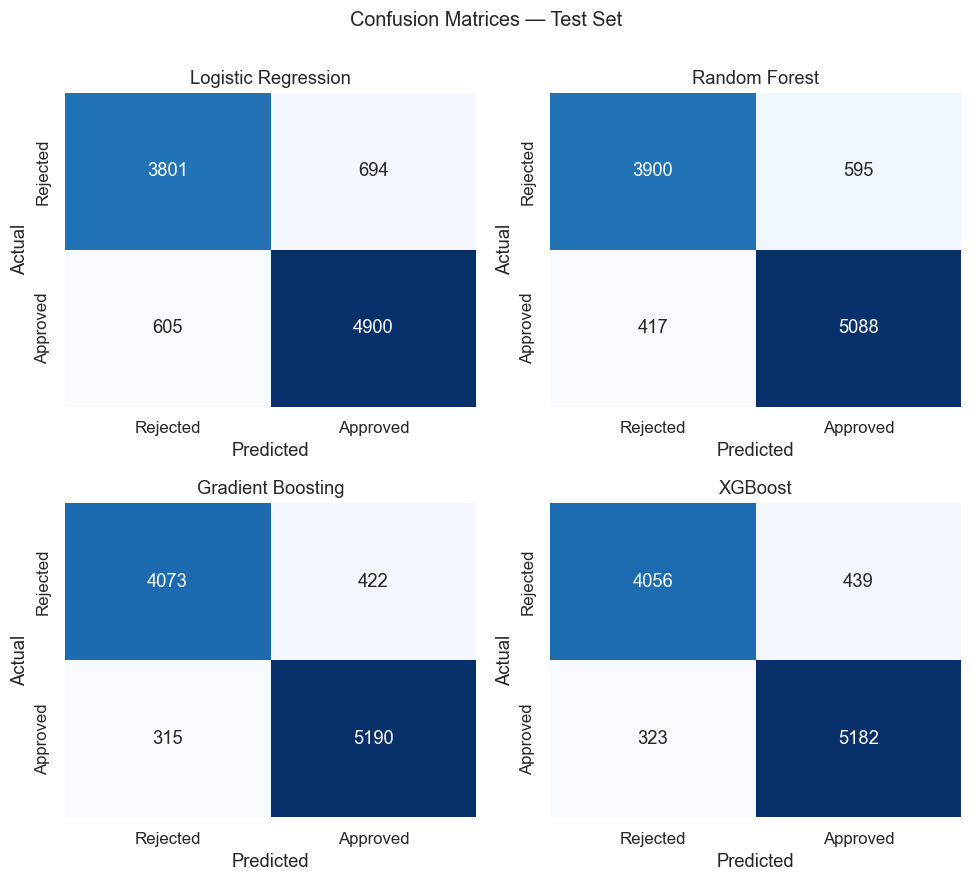

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, (name, r) in zip(axes.flat, results.items()):
    cm = confusion_matrix(y_test, r["test"]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Rejected", "Approved"],
                yticklabels=["Rejected", "Approved"], ax=ax)
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices — Test Set", y=1.00, fontsize=13)
plt.tight_layout(); plt.show()

Observations
Gradient Boosting and XGBoost models perform equally well at the top (F1 ≈ 0.934, AUC ≈ 0.98). The Random Forest model is a reliable second-tier model (F1 = 0.909). The Logistic Regression model lags behind with an F1 score of 0.883.

## 5. Fairness Analysis

Fairness assessment is done for two sensitive variables, namely age_bin (young/mid/senior), and occupation status (Employed/Self-Employed/Student). The following measures are provided for every model and every sensitive variable used:

- Selection Rate: rate at which each particular group gets a positive prediction
- True Positive Rate: per-group measure for true positives
- False Positive Rate: per-group measure for false positives
- Demographic Parity Difference: maximum disparity in selection rate
- Equalized Odds Difference: maximum disparity in True or False Positive Rate

Smaller DPD or EOD means better fairness.

In [ ]:
sens_age = X_test_fe["age_bin"].astype(str).reset_index(drop=True)
sens_occ = X_test["occupation_status"].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

fairness_rows = []
for name, r in results.items():
    y_pred = pd.Series(r["test"]["y_pred"]).reset_index(drop=True)
    for sens_name, sens in [("age_bin", sens_age),
                            ("occupation_status", sens_occ)]:
        mf = MetricFrame(
            metrics={
                "selection_rate": selection_rate,
                "tpr": true_positive_rate,
                "fpr": false_positive_rate,
                "accuracy": accuracy_score,
            },
            y_true=y_test_reset, y_pred=y_pred, sensitive_features=sens,
        )
        dpd = demographic_parity_difference(y_test_reset, y_pred,
                                            sensitive_features=sens)
        eod = equalized_odds_difference(y_test_reset, y_pred,
                                        sensitive_features=sens)
        print(f"\n-- {name} | {sens_name}")
        print(mf.by_group.round(4))
        print(f"   DPD: {dpd:.4f}   EOD: {eod:.4f}")
        for group, row in mf.by_group.iterrows():
            fairness_rows.append({
                "Model": name, "Sensitive": sens_name, "Group": group,
                "selection_rate": row["selection_rate"],
                "tpr": row["tpr"], "fpr": row["fpr"],
                "accuracy": row["accuracy"], "dpd": dpd, "eod": eod,
            })

fairness_df = pd.DataFrame(fairness_rows)


-- Logistic Regression | age_bin
         selection_rate     tpr     fpr  accuracy
age_bin                                          
mid              0.6511  0.9143  0.2012    0.8717
senior           0.8111  0.9498  0.3000    0.8965
young            0.3566  0.7949  0.1006    0.8609
   DPD: 0.4545   EOD: 0.1994

-- Logistic Regression | occupation_status
                   selection_rate     tpr     fpr  accuracy
occupation_status                                          
Employed                   0.5522  0.8894  0.1512    0.8709
Self-Employed              0.5906  0.9030  0.1651    0.8742
Student                    0.5474  0.8675  0.1571    0.8564
   DPD: 0.0433   EOD: 0.0355

-- Random Forest | age_bin
         selection_rate     tpr     fpr  accuracy
age_bin                                          
mid              0.6621  0.9464  0.1763    0.9011
senior           0.8132  0.9715  0.2300    0.9285
young            0.3641  0.8413  0.0853    0.8877
   DPD: 0.4492   EOD: 0.1447

-- Ran

### 5.1 Selection rates across groups

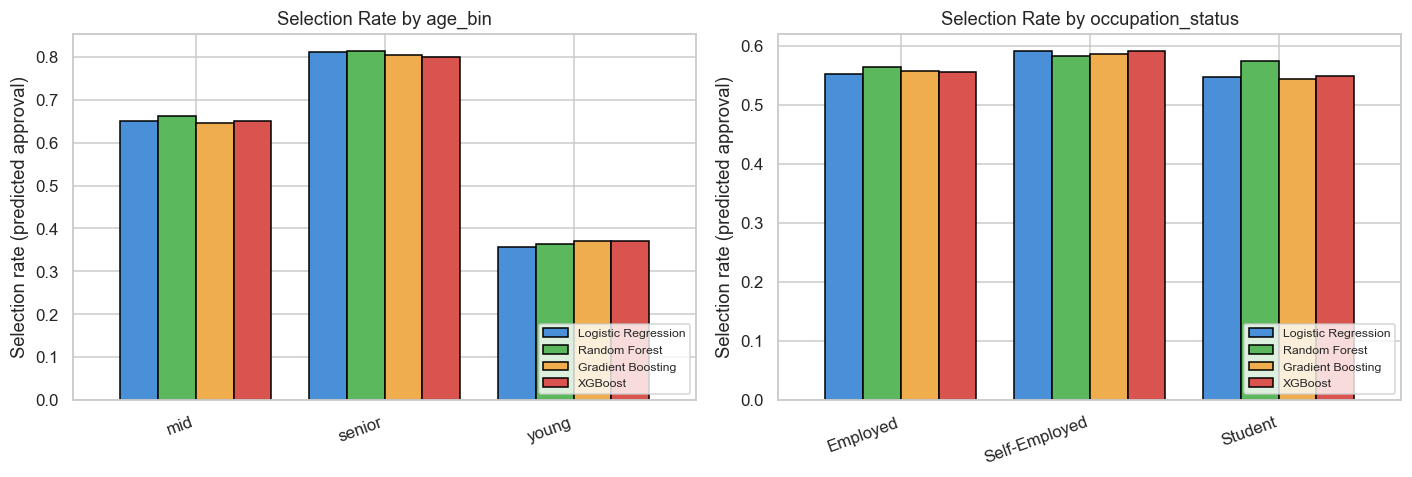

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, sens_name in zip(axes, ["age_bin", "occupation_status"]):
    sub = fairness_df[fairness_df["Sensitive"] == sens_name]
    pivot = sub.pivot(index="Group", columns="Model",
                      values="selection_rate")[list(models.keys())]
    pivot.plot(kind="bar", ax=ax, color=colors, edgecolor="black", width=0.8)
    ax.set_title(f"Selection Rate by {sens_name}")
    ax.set_ylabel("Selection rate (predicted approval)")
    ax.set_xlabel(""); ax.legend(fontsize=8, loc="lower right")
    for label in ax.get_xticklabels():
        label.set_rotation(20); label.set_ha("right")
plt.tight_layout(); plt.show()

### 5.2 Fairness summary (DPD & EOD)

In [ ]:
summary_fair = (fairness_df.groupby(["Model", "Sensitive"])[["dpd", "eod"]]
                .first().reset_index())
summary_fair.round(4)

,Model,Sensitive,dpd,eod
0,Gradient Boosting,age_bin,0.4343,0.0933
1,Gradient Boosting,occupation_status,0.0433,0.0353
2,Logistic Regression,age_bin,0.4545,0.1994
3,Logistic Regression,occupation_status,0.0433,0.0355
4,Random Forest,age_bin,0.4492,0.1447
5,Random Forest,occupation_status,0.0191,0.0185
6,XGBoost,age_bin,0.4298,0.0911
7,XGBoost,occupation_status,0.0413,0.0280


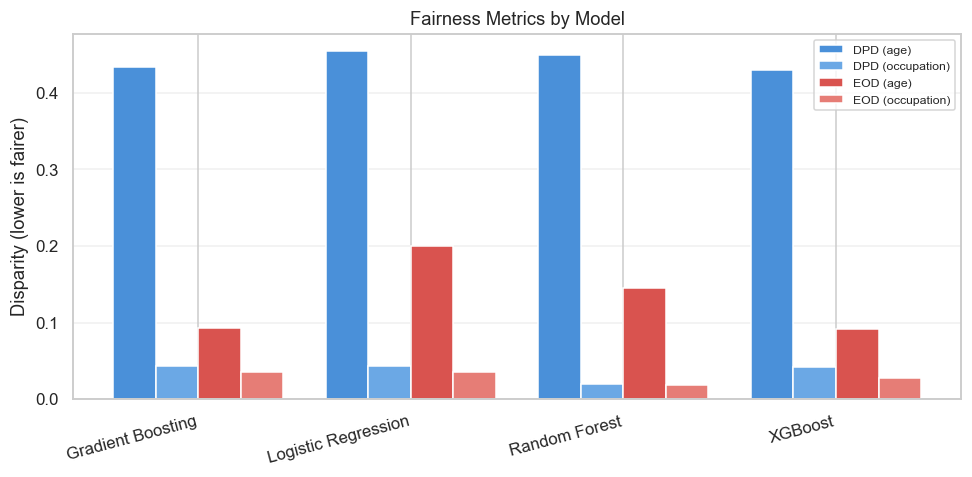

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
pivot_dpd = summary_fair.pivot(index="Model", columns="Sensitive", values="dpd")
pivot_eod = summary_fair.pivot(index="Model", columns="Sensitive", values="eod")
idx = np.arange(len(pivot_dpd.index)); width = 0.2
ax.bar(idx - 1.5*width, pivot_dpd["age_bin"],           width, label="DPD (age)",        color="#4a90d9")
ax.bar(idx - 0.5*width, pivot_dpd["occupation_status"], width, label="DPD (occupation)", color="#6ba8e5")
ax.bar(idx + 0.5*width, pivot_eod["age_bin"],           width, label="EOD (age)",        color="#d9534f")
ax.bar(idx + 1.5*width, pivot_eod["occupation_status"], width, label="EOD (occupation)", color="#e67d76")
ax.set_xticks(idx); ax.set_xticklabels(pivot_dpd.index, rotation=15, ha="right")
ax.set_ylabel("Disparity (lower is fairer)")
ax.set_title("Fairness Metrics by Model")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

**Observations.**

1. There is high disparity based on age among all the models (DPD ≈ 0.43 - 0.45). Youth is expected to be approved at about 37%, while seniors are approved at 80% probability. These numbers come from the base rates observed in the training data; youth has shorter credit history, lower savings, and less stable income.

2. Disparity according to occupation is low for all models (DPD ≤ 0.05, EOD ≤ 0.04). There is no imbalance because the three occupational categories start out with very similar base rates of approval.

3. In terms of Equalized Odds disparity on age, the boosting algorithms perform better than logistic regression (≈ 0.09 vs 0.20). Being non-linear, they are more adept at distinguishing risk factors from mere group characteristics.

## 6. SHAP Explainability

We explain the best tree-based model (by test F1) using SHAP. SHAP decomposes each prediction into per-feature contributions and provides both global feature importance and local, instance-level explanations.

In [ ]:
tree_models = ["Random Forest", "Gradient Boosting", "XGBoost"]
best_name = max(tree_models, key=lambda n: results[n]["test"]["f1"])
best_model = results[best_name]["model"]
print(f"Using {best_name} for SHAP  (F1 = {results[best_name]['test']['f1']:.4f})")

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_test_enc), size=1000, replace=False)
X_sample = X_test_enc.iloc[sample_idx]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

# Normalise SHAP output shape (RF returns list / 3D; XGBoost returns 2D)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
elif shap_values.ndim == 3:
    shap_vals = shap_values[:, :, 1]
else:
    shap_vals = shap_values
print("SHAP values shape:", shap_vals.shape)

Using Gradient Boosting for SHAP  (F1 = 0.9337)
SHAP values shape: (1000, 35)


### 6.1 Global feature importance (bar)

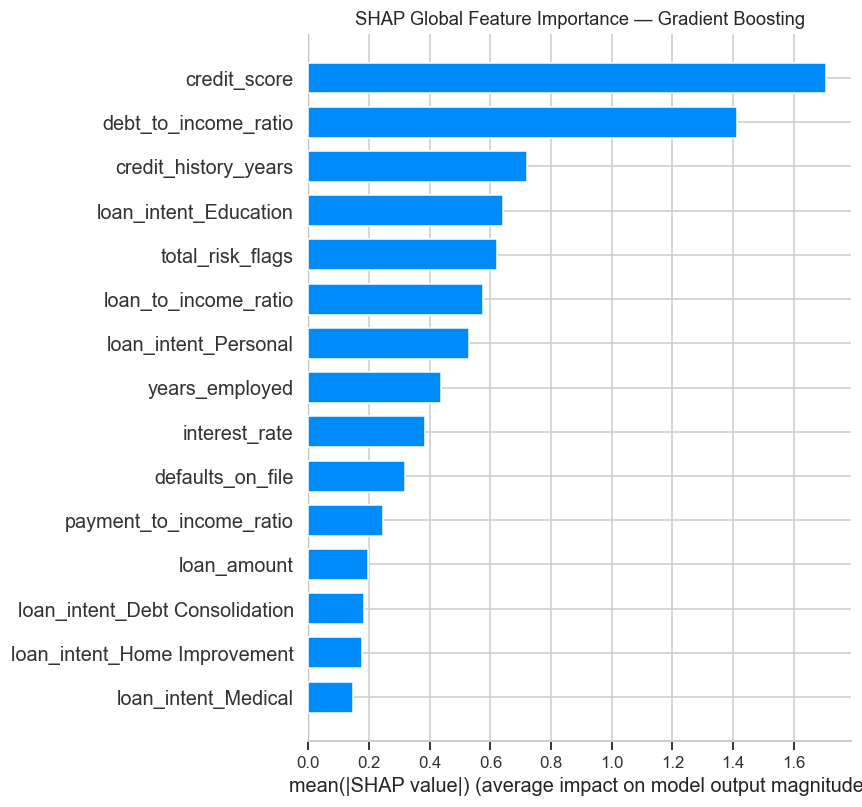

In [ ]:
shap.summary_plot(shap_vals, X_sample, plot_type="bar",
                  show=False, max_display=15)
plt.title(f"SHAP Global Feature Importance — {best_name}")
plt.tight_layout(); plt.show()

### 6.2 Directional impact (beeswarm)

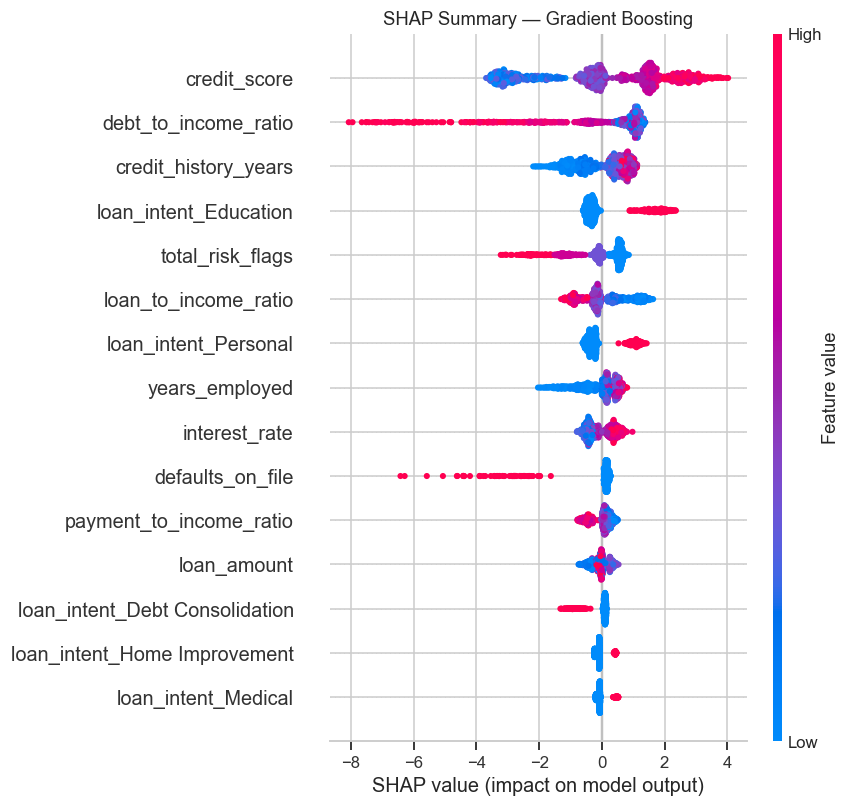

In [ ]:
shap.summary_plot(shap_vals, X_sample, show=False, max_display=15)
plt.title(f"SHAP Summary — {best_name}")
plt.tight_layout(); plt.show()

**Observations.**

- The credit score feature is most influential - high scores influence towards acceptance and low towards denial.
- debt to income ratio pushes strongly toward rejection when high.
- Next come credit history years, total risk flags, and loan to income ratio in that order; all align with domain reasoning.
- Loan purpose categorical features Education +, Debt Consolidation - have significance and relate to the base rate imbalance discovered during EDA.

-Note: Neither age nor its categories make the cut as important features, even though the model makes use of age in a different way – via the correlated features mentioned earlier (history length, savings, and job stability).

### 6.3 Top features by mean |SHAP|

In [ ]:
mean_abs = np.abs(shap_vals).mean(axis=0)
top_feats = (pd.DataFrame({"feature": X_sample.columns,
                           "mean_abs_shap": mean_abs})
             .sort_values("mean_abs_shap", ascending=False).head(15))
top_feats

,feature,mean_abs_shap
3,credit_score,1.704757
12,debt_to_income_ratio,1.412989
4,credit_history_years,0.722207
24,loan_intent_Education,0.641793
18,total_risk_flags,0.621897
13,loan_to_income_ratio,0.576709
27,loan_intent_Personal,0.528922
1,years_employed,0.438631
11,interest_rate,0.382998
7,defaults_on_file,0.318950


## 7. Summary

| Dimension | Finding |
| --- | --- |
| Best F1 (test) | Gradient Boosting 0.9338 · XGBoost 0.9337 |
| Best AUC (test) | Gradient Boosting 0.9838 · XGBoost 0.9831 |
| Baseline (LR) | F1 0.8830 · AUC 0.9476 |
| Fairness — age | Large DPD (~0.44) across all models; EOD is smaller for boosting (~0.09) than LR (~0.20) |
| Fairness — occupation | Small disparity across all models (DPD ≤ 0.05) |
| Top SHAP features | credit_score, debt_to_income_ratio, credit_history_years, total_risk_flags, loan_to_income_ratio |
